# ASWIFT SI_3-SI_7 — single-voltammogram method-fit panels

This notebook defines a reusable function for making a **5 × 4 ASWIFT-style fit grid** from five raw voltammogram CSV files.

- **Rows:** five raw voltammogram CSV files that you pass in.
- **Columns:** four peak-extraction methods.
- Each subplot shows the SWV data, fitted baseline, fitted peak + baseline, and a dashed vertical line marking the calculated signal.
- The plotted SWV data can be filtered independently with the same median-MAD outlier masking used in FIG_4.
- The fitting step is left untouched and uses the default masking/outlier handling from your existing `fit_data(...)` pipeline.
- Background, peak, and raw traces are plotted on separate x-grids when necessary, so returned curve lengths do **not** need to match exactly.
- The subplot title reports the method name and calculated signal.
- No manual axis limits or y-axis rescaling are applied.

The fitting/curve-reconstruction logic follows the same structure as `fit_visualization.py`, but is converted from an interactive Streamlit viewer into a static ASWIFT SI_X figure generator.


In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Mapping, Sequence
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter


# -----------------------------
# ASWIFT-friendly plotting defaults copied from the ASWIFT SI_X notebooks
# -----------------------------
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 9.5,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.fontsize": 9,
    "axes.linewidth": 1.0,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.default": "it",
})


def save_figure_multi(fig, stem, out_dir="figure_exports"):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_dir / f"{stem}.png", transparent=True)
    fig.savefig(out_dir / f"{stem}.pdf", transparent=True)
    fig.savefig(out_dir / f"{stem}.svg", transparent=True)
    print(f"Saved to: {out_dir.resolve()}")


METHODS = {
    "aswift": "ASWIFT",
    "poly_linear": "Polynomial",
    "plaxco_gauss": "Multi-Gaussian",
    "justine_ewd": "Extend-Wavelet",
}

METHOD_STYLE = {
    "aswift": {
        "color": "#1f77b4",
        "marker": "o",
        "linestyle": "-",
        "linewidth": 1.35,
        "markersize": 5.0,
        "zorder": 20.0,
    },
    "poly_linear": {
        "color": "#ff7f0e",
        "marker": "o",
        "linestyle": "-",
        "linewidth": 1.35,
        "markersize": 5.0,
        "zorder": 3.0,
    },
    "plaxco_gauss": {
        "color": "#2ca02c",
        "marker": "o",
        "linestyle": "-",
        "linewidth": 1.35,
        "markersize": 5.0,
        "zorder": 3.0,
    },
    "justine_ewd": {
        "color": "#d62728",
        "marker": "o",
        "linestyle": "-",
        "linewidth": 1.35,
        "markersize": 5.0,
        "zorder": 3.0,
    },
}


def _format_signal(x: float) -> str:
    if not np.isfinite(x):
        return "nan"
    if abs(x) >= 1e3 or (0 < abs(x) < 1e-2):
        return f"{x:.2e}"
    return f"{x:.3g}"


def _short_path_label(path: str | Path) -> str:
    path = Path(path)
    stem = path.stem
    return stem if len(stem) <= 38 else stem[:35] + "..."


def read_voltammogram_csv_all(csv_path: str | Path):
    """Read a BioLogic-style SWV CSV: voltage in the first column, channels in odd columns."""
    csv_path = Path(csv_path)
    df = (
        pd.read_csv(csv_path, skiprows=6, encoding="utf-16")
        .apply(pd.to_numeric, errors="coerce")
        .dropna()
    )
    volts = df.iloc[:, 0].astype(float).to_numpy()
    currents = df.iloc[:, 1::2].dropna(how="all").astype(float).to_numpy().T
    return volts, currents


def read_voltammogram_csv(csv_path: str | Path, channel: int = 0):
    volts, currents = read_voltammogram_csv_all(csv_path)
    if channel >= currents.shape[0]:
        raise IndexError(
            f"Requested channel {channel}, but {Path(csv_path).name} only has "
            f"{currents.shape[0]} detected current channel(s)."
        )
    return volts, currents[channel]


In [2]:
def setup_peak_extraction_imports(
    *,
    config_path: str | Path | None = None,
    project_root: str | Path | None = None,
):
    """
    Import project-specific peak-extraction functions and optionally load a config file.

    Parameters
    ----------
    config_path
        Path to the same config file you would pass to your peak-extraction scripts.
        Leave as None if the config has already been loaded elsewhere in the notebook.
    project_root
        Optional path to add to sys.path before importing `peak_extraction`.
    """
    if project_root is not None:
        project_root = str(Path(project_root).expanduser())
        if project_root not in sys.path:
            sys.path.insert(0, project_root)

    from peak_extraction.config import load_config, config
    from peak_extraction.extract_peaks import (
        fit_data,
        calculate_gaussian_background,
        calculate_poly_background,
        calculate_linear_background,
        calculate_t_background,
        calculate_solved_background,
        single_gaussian,
        single_t_distribution,
        poly_calculator,
        linear_calculator,
        calculate_solved_peak,
    )

    try:
        from peak_extraction.extract_peaks import mask_multichannel_outliers
    except ImportError:
        mask_multichannel_outliers = None

    if config_path is not None:
        load_config(str(Path(config_path).expanduser()))

    bg_methods = {
        "gaussian": calculate_gaussian_background,
        "polynomial": calculate_poly_background,
        "linear": calculate_linear_background,
        "t": calculate_t_background,
        "derpsalsa": calculate_solved_background,
        "derpsalsa_iter": calculate_solved_background,
        "tikhonov": calculate_solved_background,
    }
    pk_methods = {
        "gaussian": single_gaussian,
        "t": single_t_distribution,
        "t_huber": single_t_distribution,
        "tikhonov": calculate_solved_peak,
    }

    return {
        "config": config,
        "fit_data": fit_data,
        "bg_methods": bg_methods,
        "pk_methods": pk_methods,
        "single_gaussian": single_gaussian,
        "calculate_gaussian_background": calculate_gaussian_background,
        "poly_calculator": poly_calculator,
        "linear_calculator": linear_calculator,
        "calculate_solved_peak": calculate_solved_peak,
        "calculate_solved_background": calculate_solved_background,
        "mask_multichannel_outliers": mask_multichannel_outliers,
    }


def resolve_method_functions(method: str, env: dict):
    """
    Return peak/background functions for reconstructing fits from fit_data output.

    This mirrors the dispatch logic used in `fit_visualization.py`, with explicit handling
    for the four comparison methods used in the ASWIFT ASWIFT figures.
    """
    config = env["config"]

    if method == "plaxco_gauss":
        return {
            "pk_method": env["single_gaussian"],
            "bg_method": env["calculate_gaussian_background"],
            "pk_method_name": "gaussian",
            "bg_method_name": "multi-gaussian",
        }

    if method in {"poly_linear", "poly_original"}:
        return {
            "pk_method": env["poly_calculator"],
            "bg_method": env["linear_calculator"],
            "pk_method_name": "polynomial",
            "bg_method_name": "linear",
        }

    if method == "norm_trds":
        return {
            "pk_method": env["calculate_solved_peak"],
            "bg_method": env["calculate_solved_background"],
            "pk_method_name": "norm tikhonov",
            "bg_method_name": "derpsalsa",
        }

    if method == "justine_ewd":
        return {
            "pk_method": env["calculate_solved_peak"],
            "bg_method": env["calculate_solved_background"],
            "pk_method_name": "ewd",
            "bg_method_name": "arbitrary minimum",
        }

    # Fallback for any other method in your config.
    # This intentionally matches the logic of fit_visualization.py.
    pk_method_name = getattr(config.parameters, "peak_method")
    bg_method_name = getattr(config.parameters, "background_method")
    pk_method = env["pk_methods"].get(pk_method_name)
    bg_method = env["bg_methods"].get(bg_method_name)

    if pk_method is None:
        raise RuntimeError(f"{pk_method_name!r} peak method unsupported")
    if bg_method is None:
        raise RuntimeError(f"{bg_method_name!r} background method unsupported")

    return {
        "pk_method": pk_method,
        "bg_method": bg_method,
        "pk_method_name": pk_method_name,
        "bg_method_name": bg_method_name,
    }


def _finite_xy(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    keep = np.isfinite(x) & np.isfinite(y)
    return x[keep], y[keep]


def _curve_x_for_length(reference_x: np.ndarray, n: int) -> np.ndarray:
    """
    Return an x-grid for a curve with length `n` when a method returns a curve whose
    length differs from the reference SWV voltage grid.

    Most length mismatches in these fits arise because a smoother/mask trims a small
    number of edge points. If the mismatch is small, use the centered slice of the
    reference grid, e.g. 419 -> 417 becomes x[1:-1]. If the mismatch is larger or the
    method returns more points than the reference, fall back to an evenly spaced grid
    over the same voltage range. This keeps plotting robust without forcing shapes to
    match by truncation.
    """
    reference_x = np.asarray(reference_x, dtype=float)
    reference_x = reference_x[np.isfinite(reference_x)]
    if n <= 0:
        return np.asarray([], dtype=float)
    if reference_x.size == 0:
        return np.arange(n, dtype=float)
    if n == reference_x.size:
        return reference_x.copy()
    if n < reference_x.size:
        diff = reference_x.size - n
        # Typical case: the fitted object is a centered, edge-trimmed version of x.
        if diff <= 20:
            start = diff // 2
            return reference_x[start:start + n].copy()
        return np.linspace(float(np.nanmin(reference_x)), float(np.nanmax(reference_x)), n)
    return np.linspace(float(np.nanmin(reference_x)), float(np.nanmax(reference_x)), n)


def _curve_with_own_x(y, reference_x: np.ndarray, *, name: str):
    """
    Convert method output to a 1D curve and its own x-grid.

    This deliberately does *not* require the output curve to have the same length as
    `reference_x`. That matters for methods whose default fitting/outlier handling
    internally drops voltage points.
    """
    arr = np.asarray(y, dtype=float)
    if arr.ndim == 0:
        x = np.asarray(reference_x, dtype=float)
        return x, np.full_like(x, float(arr), dtype=float)
    arr = np.ravel(arr).astype(float)
    if arr.size == 1:
        x = np.asarray(reference_x, dtype=float)
        return x, np.full_like(x, float(arr[0]), dtype=float)
    x = _curve_x_for_length(reference_x, arr.size)
    if x.size != arr.size:
        # This should be rare, but keeps the failure mode explicit and easy to debug.
        raise ValueError(f"{name} produced {arr.size} y-points but only {x.size} x-points could be assigned.")
    keep = np.isfinite(x) & np.isfinite(arr)
    return x[keep], arr[keep]


def _interp_curve(target_x: np.ndarray, source_x: np.ndarray, source_y: np.ndarray) -> np.ndarray:
    """Safely interpolate one curve onto another x-grid, returning NaN outside support."""
    target_x = np.asarray(target_x, dtype=float)
    source_x = np.asarray(source_x, dtype=float)
    source_y = np.asarray(source_y, dtype=float)
    keep = np.isfinite(source_x) & np.isfinite(source_y)
    source_x = source_x[keep]
    source_y = source_y[keep]
    if source_x.size < 2:
        return np.full_like(target_x, np.nan, dtype=float)
    order = np.argsort(source_x)
    source_x = source_x[order]
    source_y = source_y[order]
    # Remove duplicate x-values because np.interp expects a strictly increasing grid.
    unique_x, unique_idx = np.unique(source_x, return_index=True)
    unique_y = source_y[unique_idx]
    if unique_x.size < 2:
        return np.full_like(target_x, np.nan, dtype=float)
    return np.interp(target_x, unique_x, unique_y, left=np.nan, right=np.nan)



def _coerce_masked_currents(masked_currents: np.ndarray, *, expected_channels: int):
    """Normalize mask_multichannel_outliers output to shape (channels, points)."""
    arr = np.asarray(masked_currents, dtype=float)
    if arr.ndim == 1:
        if expected_channels != 1:
            raise ValueError(
                "mask_multichannel_outliers returned a 1D current array, but the input had "
                f"{expected_channels} channels."
            )
        arr = arr[np.newaxis, :]
    return arr


def _apply_fig_4_raw_mask(
    volts: np.ndarray,
    all_currents: np.ndarray,
    *,
    env: dict,
    raw_data_outlier_kwargs: dict | None = None,
):
    """
    Apply the raw-trace masker using the same data shape and call pattern as FIG_4.

    FIG_4 does this:
        v, all_currents = mask_multichannel_outliers(v, all_currents, **trace_outlier_kwargs)

    where `all_currents` has shape (channels, voltage_points). The selected channel is
    extracted only after masking. This matters because masking one channel at a time can
    fail to reproduce the FIG_4 behavior.
    """
    volts = np.asarray(volts, dtype=float)
    all_currents = np.asarray(all_currents, dtype=float)

    if all_currents.ndim == 1:
        all_currents = all_currents[np.newaxis, :]

    if all_currents.ndim != 2:
        raise ValueError(f"Expected all_currents to be 2D, got shape {all_currents.shape}.")

    if all_currents.shape[1] != volts.size:
        raise ValueError(
            f"Voltage array has {volts.size} points, but current matrix has "
            f"{all_currents.shape[1]} voltage points."
        )

    finite_cols = np.isfinite(volts) & np.any(np.isfinite(all_currents), axis=0)
    volts = volts[finite_cols]
    all_currents = all_currents[:, finite_cols]

    if raw_data_outlier_kwargs is None:
        return volts, all_currents

    mask_multichannel_outliers = env.get("mask_multichannel_outliers")
    if mask_multichannel_outliers is None:
        raise RuntimeError(
            "raw_data_outlier_kwargs was provided, but `mask_multichannel_outliers` could not be imported "
            "from peak_extraction.extract_peaks. Set raw_data_outlier_kwargs=None to disable this step."
        )

    masked_v, masked_currents = mask_multichannel_outliers(
        volts,
        all_currents,
        **raw_data_outlier_kwargs,
    )

    masked_v = np.asarray(masked_v, dtype=float)
    masked_currents = _coerce_masked_currents(
        masked_currents,
        expected_channels=all_currents.shape[0],
    )

    if masked_currents.shape[0] != all_currents.shape[0]:
        raise ValueError(
            "mask_multichannel_outliers changed the number of channels from "
            f"{all_currents.shape[0]} to {masked_currents.shape[0]}."
        )

    # Some implementations return the same voltage length with outliers set to NaN;
    # others return shortened arrays. Both are accepted, but the voltage/current
    # dimensions must still agree after masking.
    if masked_currents.shape[1] != masked_v.size:
        raise ValueError(
            "mask_multichannel_outliers returned incompatible shapes: "
            f"voltage has {masked_v.size} points, current matrix has "
            f"{masked_currents.shape[1]} points."
        )

    return masked_v, masked_currents


def filter_voltammogram_data_by_mad(
    volts: np.ndarray,
    all_currents: np.ndarray,
    *,
    channel: int,
    env: dict,
    raw_data_outlier_kwargs: dict | None = None,
):
    """
    Apply the FIG_4 median-MAD outlier masker to the *plotted raw data only*.

    This intentionally masks the full multichannel dataset first, then extracts the
    requested channel, matching the FIG_4 raw-trace workflow.

    This does not change the data used by `fit_data`; the fitting pipeline keeps its own
    default masking/outlier behavior.

    Pass `raw_data_outlier_kwargs=None` to plot every finite raw point.
    Pass `raw_data_outlier_kwargs={}` to use the defaults from `mask_multichannel_outliers`.
    """
    masked_v, masked_currents = _apply_fig_4_raw_mask(
        volts,
        all_currents,
        env=env,
        raw_data_outlier_kwargs=raw_data_outlier_kwargs,
    )

    if channel >= masked_currents.shape[0]:
        raise IndexError(
            f"Requested channel {channel}, but the masked current matrix only has "
            f"{masked_currents.shape[0]} channel(s)."
        )

    masked_i = masked_currents[channel]
    return _finite_xy(masked_v, masked_i)


def fit_single_voltammogram_for_method(
    csv_path: str | Path,
    *,
    method: str,
    channel: int = 0,
    env: dict,
    raw_data_outlier_kwargs: dict | None = None,
):
    """
    Fit one raw voltammogram CSV using one method and reconstruct the displayed curves.

    The plotted data and fitted curves deliberately use independent x-arrays:
    - plotted data can be shortened by median-MAD outlier filtering;
    - `fit_data` keeps its own default fitting/masking behavior;
    - returned peak/background arrays are plotted against the x-grid that matches each
      returned array length instead of being forced to match the raw trace length.

    This prevents shape-mismatch errors such as a 417-point background returned for a
    419-point raw voltage grid.
    """
    csv_path = Path(csv_path)

    raw_volts, raw_currents_all = read_voltammogram_csv_all(csv_path)
    if channel >= raw_currents_all.shape[0]:
        raise IndexError(
            f"Requested channel {channel}, but {csv_path.name} only has "
            f"{raw_currents_all.shape[0]} detected current channel(s)."
        )
    raw_current = raw_currents_all[channel]

    data_volts, data_current = filter_voltammogram_data_by_mad(
        raw_volts,
        raw_currents_all,
        channel=channel,
        env=env,
        raw_data_outlier_kwargs=raw_data_outlier_kwargs,
    )

    fit_reference_volts, _ = _finite_xy(raw_volts, raw_current)
    method_fns = resolve_method_functions(method, env)

    # Important: do not pass raw_data_outlier_kwargs into fit_data.
    # The fitting method uses whatever default masking/outlier handling your config defines.
    fit_results = env["fit_data"](str(csv_path), method=method)
    selected = None
    for channel_index, peak_signal, background_signal, bg_idx, popt in fit_results:
        if int(channel_index) == int(channel):
            selected = (channel_index, peak_signal, background_signal, bg_idx, popt)
            break

    if selected is None:
        raise RuntimeError(f"No fit result found for channel {channel} in {csv_path.name} using {method}.")

    channel_index, peak_signal, background_signal, bg_idx, popt = selected
    popt = np.asarray(popt, dtype=float)

    if popt.size == 0 or not np.isfinite(popt[0]):
        raise RuntimeError(f"Fit failed for {csv_path.name} using {method}.")

    bg_idx = int(bg_idx)
    pk_method = method_fns["pk_method"]
    bg_method = method_fns["bg_method"]

    bg_x, background = _curve_with_own_x(
        bg_method(fit_reference_volts, popt[bg_idx:]),
        fit_reference_volts,
        name="background",
    )
    peak_x, peak = _curve_with_own_x(
        pk_method(fit_reference_volts, *popt[:bg_idx]),
        fit_reference_volts,
        name="peak",
    )

    # Construct the displayed combined fit by interpolating the background onto the peak grid.
    # The background and peak are still plotted separately on their own native grids.
    bg_on_peak_x = _interp_curve(peak_x, bg_x, background)
    fitted_x = peak_x
    fitted = peak + bg_on_peak_x
    keep_fit = np.isfinite(fitted_x) & np.isfinite(fitted)
    fitted_x = fitted_x[keep_fit]
    fitted = fitted[keep_fit]

    finite_peak = np.isfinite(peak)
    if np.any(finite_peak):
        # Use the largest absolute fitted peak contribution so negative-going peaks are handled too.
        peak_idx = int(np.nanargmax(np.where(finite_peak, np.abs(peak), np.nan)))
        peak_voltage = float(peak_x[peak_idx])
        peak_value = float(peak[peak_idx])
        peak_background = float(_interp_curve(np.array([peak_voltage]), bg_x, background)[0])
        peak_total = peak_background + peak_value if np.isfinite(peak_background) else np.nan
    else:
        # Last-resort fallback: compare filtered plotted data to the background interpolated onto data_volts.
        bg_on_data = _interp_curve(data_volts, bg_x, background)
        peak_idx_data = int(np.nanargmax(np.abs(data_current - bg_on_data)))
        peak_voltage = float(data_volts[peak_idx_data])
        peak_value = np.nan
        peak_background = float(bg_on_data[peak_idx_data])
        peak_total = np.nan
        peak_idx = None

    return {
        "csv_path": csv_path,
        "method": method,
        "channel": channel,
        "data_volts": data_volts,
        "data_current": data_current,
        "bg_x": bg_x,
        "background": background,
        "peak_x": peak_x,
        "peak": peak,
        "fitted_x": fitted_x,
        "fitted": fitted,
        "peak_idx": peak_idx,
        "peak_voltage": peak_voltage,
        "peak_value": peak_value,
        "peak_background": peak_background,
        "peak_total": peak_total,
        "peak_signal": float(peak_signal),
        "background_signal": float(background_signal),
        "pk_method_name": method_fns["pk_method_name"],
        "bg_method_name": method_fns["bg_method_name"],
        "n_raw_points": int(np.isfinite(raw_volts).sum()),
        "n_plotted_points": int(data_volts.size),
        "n_background_points": int(background.size),
        "n_peak_points": int(peak.size),
    }


In [3]:
def plot_si_fit_grid(
    voltammogram_csv_paths: Sequence[str | Path],
    *,
    config_path: str | Path | None = None,
    project_root: str | Path | None = None,
    channel: int = 0,
    methods: Mapping[str, str] = METHODS,
    row_labels: Sequence[str] | None = None,
    raw_data_outlier_kwargs: dict | None = {},
    data_outlier_kwargs: dict | None = None,
    show_removed_points_note: bool = False,
    show_fit_point_counts: bool = False,
    figure_size: tuple[float, float] = (11.0, 12.0),
    save_stem: str | None = None,
    out_dir: str | Path = "figure_exports",
):
    """
    Plot a 5 × 4 grid of raw voltammogram fits.

    Method labels are shown only on the first row. Row trace labels are bolded
    on the left-hand axis.

    Parameters
    ----------
    voltammogram_csv_paths
        Exactly five raw voltammogram CSV paths. Each path becomes one row.
    config_path
        Path to the project config file. Use the same config that you would use for
        peak extraction. Can be omitted if the config is already loaded.
    project_root
        Optional project root to insert into sys.path before importing `peak_extraction`.
    channel
        Current channel to plot from each SWV CSV.
    methods
        Mapping from method key to display label. Defaults to the four ASWIFT comparison methods.
    row_labels
        Optional labels for the five rows. Defaults to shortened CSV basenames.
    raw_data_outlier_kwargs
        Median-MAD outlier filtering kwargs passed to `mask_multichannel_outliers` for the
        *plotted raw data only*, matching the FIG_4 raw-trace workflow.
        Use `{}` to apply the masker with its defaults. Use `None` to plot all finite raw points.
        This does not change the fitting, which keeps the method/config defaults.
    data_outlier_kwargs
        Backward-compatible alias for `raw_data_outlier_kwargs`. Prefer `raw_data_outlier_kwargs`.
    show_removed_points_note
        If True, adds a small note to each panel giving the number of plotted points after filtering.
    show_fit_point_counts
        If True, annotates the background/peak point counts. Useful for debugging length mismatches.
    figure_size
        Matplotlib figure size in inches.
    save_stem
        If not None, saves PNG/PDF/SVG using this stem.
    out_dir
        Output folder for saved files.
    """
    if data_outlier_kwargs is not None:
        raw_data_outlier_kwargs = data_outlier_kwargs

    paths = [Path(p).expanduser() for p in voltammogram_csv_paths]
    if len(paths) != 5:
        raise ValueError(f"Expected exactly 5 voltammogram CSV paths, got {len(paths)}.")
    missing = [str(p) for p in paths if not p.exists()]
    if missing:
        raise FileNotFoundError("Missing voltammogram CSV file(s):\n" + "\n".join(missing))

    env = setup_peak_extraction_imports(config_path=config_path, project_root=project_root)

    method_items = list(methods.items())
    n_rows = len(paths)
    n_cols = len(method_items)
    if n_cols != 4:
        print(f"Warning: this SI layout was designed for 4 methods, but received {n_cols}.")

    if row_labels is None:
        row_labels = [_short_path_label(p) for p in paths]
    if len(row_labels) != n_rows:
        raise ValueError(f"Expected {n_rows} row labels, got {len(row_labels)}.")

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=figure_size,
        sharex=False,
        sharey=False,
        constrained_layout=False,
    )
    axes = np.asarray(axes)

    for row_idx, (csv_path, row_label) in enumerate(zip(paths, row_labels)):
        for col_idx, (method, method_label) in enumerate(method_items):
            ax = axes[row_idx, col_idx]
            style = METHOD_STYLE.get(method, METHOD_STYLE.get("aswift", {}))
            method_color = style.get("color", "#1f77b4")

            try:
                result = fit_single_voltammogram_for_method(
                    csv_path,
                    method=method,
                    channel=channel,
                    env=env,
                    raw_data_outlier_kwargs=raw_data_outlier_kwargs,
                )

                data_volts = result["data_volts"]
                data_current = result["data_current"]
                bg_x = result["bg_x"]
                background = result["background"]
                fitted_x = result["fitted_x"]
                fitted = result["fitted"]
                peak_voltage = result["peak_voltage"]
                peak_background = result["peak_background"]
                peak_total = result["peak_total"]
                signal = result["peak_signal"]

                ax.scatter(
                    data_volts,
                    data_current,
                    s=5,
                    linewidths=0,
                    color="0.35",
                    alpha=0.75,
                    rasterized=True,
                    zorder=1,
                )
                ax.plot(
                    fitted_x,
                    fitted,
                    color=method_color,
                    linewidth=1.35,
                    zorder=4,
                )
                ax.plot(
                    bg_x,
                    background,
                    color="black",
                    linewidth=1.0,
                    zorder=3,
                )
                if np.isfinite(peak_voltage) and np.isfinite(peak_background) and np.isfinite(peak_total):
                    ax.vlines(
                        peak_voltage,
                        ymin=peak_background,
                        ymax=peak_total,
                        color=method_color,
                        linestyle=(0, (3.0, 2.0)),
                        linewidth=1.15,
                        zorder=5,
                    )
                # Use separate title text objects so only the method name is bold.
                # The calculated signal line remains normal-weight, including in the first row.
                ax.set_title("")
                if row_idx == 0:
                    ax.text(
                        0.5,
                        1.115,
                        method_label,
                        transform=ax.transAxes,
                        ha="center",
                        va="bottom",
                        fontsize=9.5,
                        fontweight="bold",
                        clip_on=False,
                    )
                    ax.text(
                        0.5,
                        1.045,
                        f"Signal = {_format_signal(signal)}",
                        transform=ax.transAxes,
                        ha="center",
                        va="bottom",
                        fontsize=9.0,
                        fontweight="normal",
                        clip_on=False,
                    )
                else:
                    ax.text(
                        0.5,
                        1.045,
                        f"Signal = {_format_signal(signal)}",
                        transform=ax.transAxes,
                        ha="center",
                        va="bottom",
                        fontsize=9.0,
                        fontweight="normal",
                        clip_on=False,
                    )

                if show_removed_points_note and result["n_raw_points"] != result["n_plotted_points"]:
                    ax.text(
                        0.03,
                        0.04,
                        f"n={result['n_plotted_points']}/{result['n_raw_points']}",
                        transform=ax.transAxes,
                        ha="left",
                        va="bottom",
                        fontsize=6.5,
                        color="0.25",
                    )
                if show_fit_point_counts:
                    ax.text(
                        0.03,
                        0.96,
                        f"bg={result['n_background_points']}, pk={result['n_peak_points']}",
                        transform=ax.transAxes,
                        ha="left",
                        va="top",
                        fontsize=6.2,
                        color="0.25",
                    )

            except Exception as exc:
                try:
                    raw_volts, raw_current = read_voltammogram_csv(csv_path, channel=channel)
                    data_volts, data_current = filter_voltammogram_data_by_mad(
                        raw_volts,
                        raw_current,
                        env=env,
                        raw_data_outlier_kwargs=raw_data_outlier_kwargs,
                    )
                    ax.scatter(
                        data_volts,
                        data_current,
                        s=5,
                        linewidths=0,
                        color="0.35",
                        alpha=0.75,
                        rasterized=True,
                    )
                except Exception:
                    pass
                if row_idx == 0:
                    ax.set_title(
                        f"{method_label}\nFit failed",
                        pad=4.5,
                        fontweight="bold",
                    )
                else:
                    ax.set_title("Fit failed", pad=4.5)
                ax.text(
                    0.03,
                    0.97,
                    str(exc),
                    transform=ax.transAxes,
                    ha="left",
                    va="top",
                    fontsize=6.5,
                    color="0.25",
                    wrap=True,
                )

            # ASWIFT-style axes. No manual x/y limits are set.
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.grid(False)
            ax.tick_params(length=3.5, width=0.9)
            ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))

            if row_idx == n_rows - 1:
                ax.set_xlabel(r"Potential, $V$")
            else:
                ax.set_xlabel("")
                ax.tick_params(labelbottom=False)

            if col_idx == 0:
                # Keep the axis quantity normal-weight, while the trace/row label is bold and offset far enough left to avoid overlap.
                ax.set_ylabel(r"Current, $\mu A$", fontweight="normal", labelpad=18)
                ax.text(
                    -0.36,
                    0.5,
                    str(row_label),
                    transform=ax.transAxes,
                    rotation=90,
                    ha="center",
                    va="center",
                    fontsize=10,
                    fontweight="bold",
                    clip_on=False,
                )
            else:
                ax.set_ylabel("")
                ax.tick_params(labelleft=False)

    fig.subplots_adjust(
        left=0.165,
        right=0.992,
        top=0.965,
        bottom=0.075,
        wspace=0.18,
        hspace=0.40,
    )

    if save_stem is not None:
        save_figure_multi(fig, save_stem, out_dir=out_dir)

    return fig, axes



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Saved to: /Users/Max_1/PycharmProjects/aswift_figures/figures/figure_exports


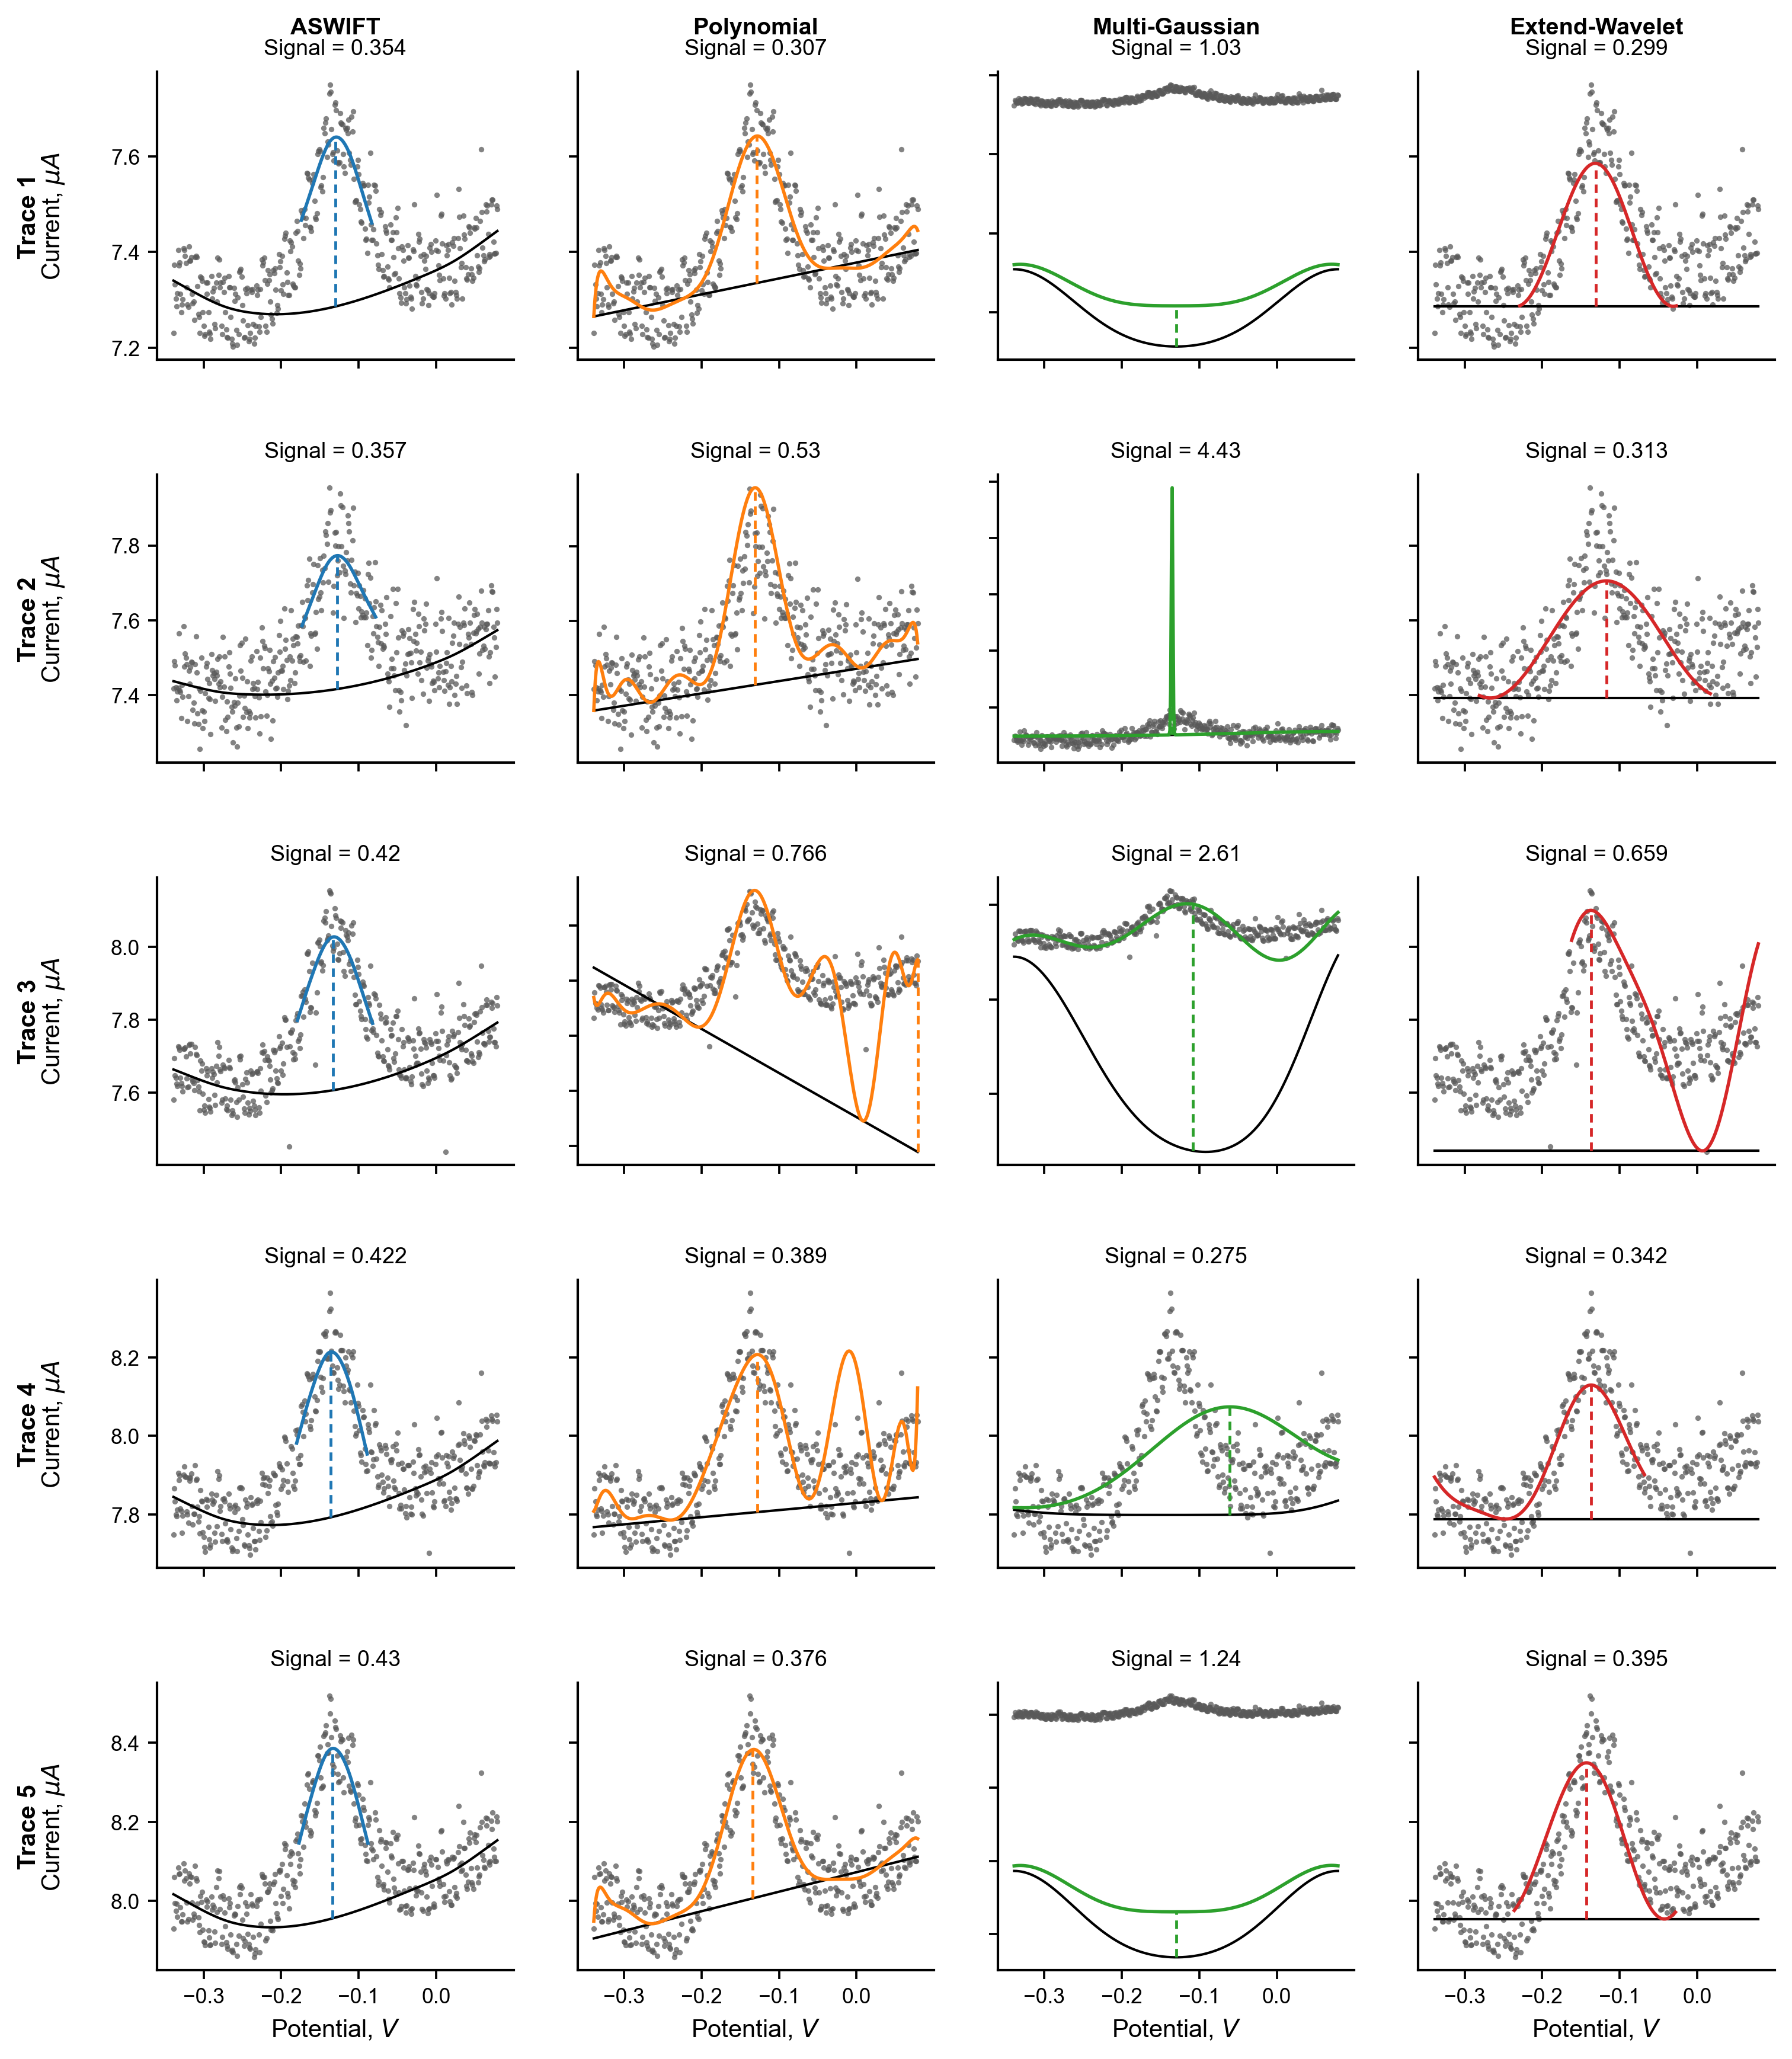

In [4]:
PROJECT_ROOT = None
CONFIG_PATH = Path('../peak_extraction/config/example_config.toml')

voltammogram_csv_paths = [
    Path('/Users/Max_1/Soh Lab/echem/20250502_Fig5a_BICEP_csv/200hz.csv'),
    Path('/Users/Max_1/Soh Lab/echem/20250502_Fig5a_BICEP_csv/200hz-45.csv'),
    Path('/Users/Max_1/Soh Lab/echem/20250502_Fig5a_BICEP_csv/200hz-97.csv'),
    Path('/Users/Max_1/Soh Lab/echem/20250502_Fig5a_BICEP_csv/200hz-168.csv'),
    Path('/Users/Max_1/Soh Lab/echem/20250502_Fig5a_BICEP_csv/200hz-224.csv'),
]

row_labels = [
    'Trace 1',
    'Trace 2',
    'Trace 3',
    'Trace 4',
    'Trace 5',
]

# Use {} for the default mask_multichannel_outliers settings.
# Use None to plot every finite raw point.
raw_data_outlier_kwargs = {}

fig, axes = plot_si_fit_grid(
    voltammogram_csv_paths,
    config_path=CONFIG_PATH,
    project_root=PROJECT_ROOT,
    channel=0,
    row_labels=row_labels,
    raw_data_outlier_kwargs=raw_data_outlier_kwargs,
    save_stem='SI_3',
)
plt.show()


Saved to: /Users/Max_1/PycharmProjects/aswift_figures/figures/figure_exports


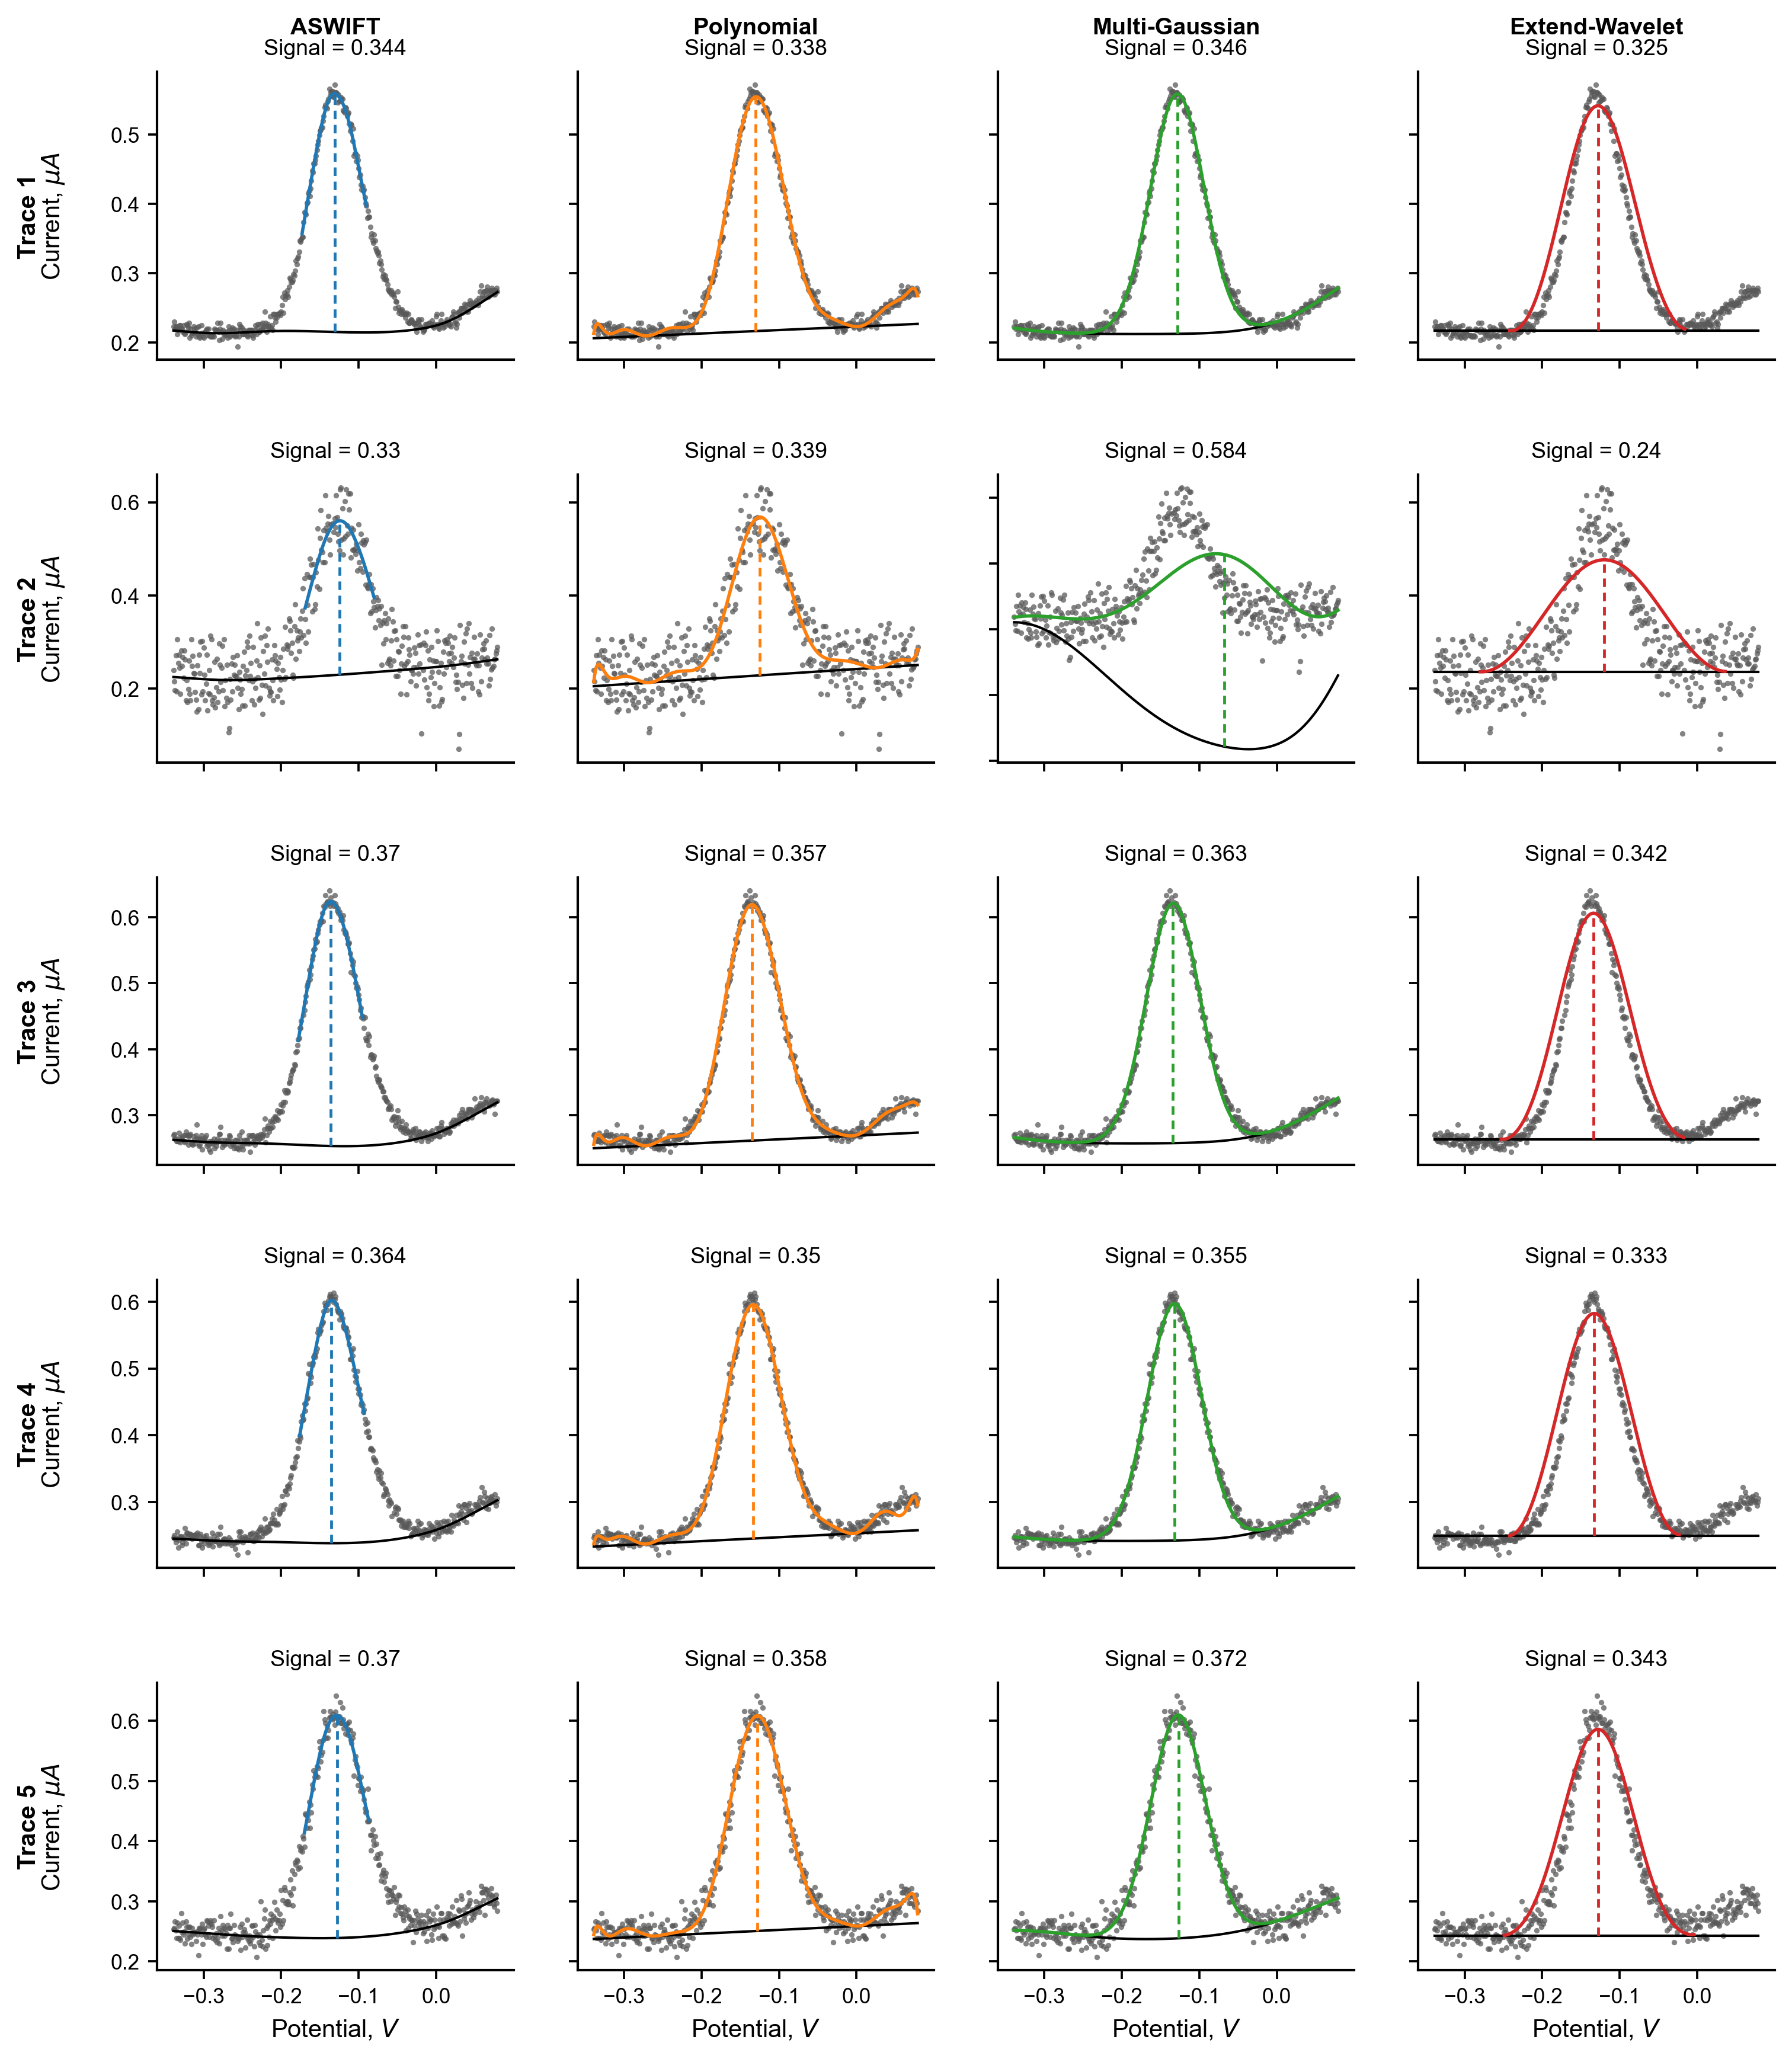

In [5]:
PROJECT_ROOT = None
CONFIG_PATH = Path('../peak_extraction/config/example_config.toml')

voltammogram_csv_paths = [
    Path('/Users/Max_1/Soh Lab/echem/20250502_Fig5a_BICEP_csv/200hz.csv'),
    Path('/Users/Max_1/Soh Lab/echem/20250502_Fig5a_BICEP_csv/200hz-45.csv'),
    Path('/Users/Max_1/Soh Lab/echem/20250502_Fig5a_BICEP_csv/200hz-113.csv'),
    Path('/Users/Max_1/Soh Lab/echem/20250502_Fig5a_BICEP_csv/200hz-169.csv'),
    Path('/Users/Max_1/Soh Lab/echem/20250502_Fig5a_BICEP_csv/200hz-228.csv'),
]

row_labels = [
    'Trace 1',
    'Trace 2',
    'Trace 3',
    'Trace 4',
    'Trace 5',
]

# Use {} for the default mask_multichannel_outliers settings.
# Use None to plot every finite raw point.
raw_data_outlier_kwargs = {}

fig, axes = plot_si_fit_grid(
    voltammogram_csv_paths,
    config_path=CONFIG_PATH,
    project_root=PROJECT_ROOT,
    channel=1,
    row_labels=row_labels,
    raw_data_outlier_kwargs=raw_data_outlier_kwargs,
    save_stem='SI_4',
)
plt.show()


/Users/Max_1/PycharmProjects/aswift_figures/peak_extraction/extract_peaks.py:1088: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(volts, cur0, degree)
/Users/Max_1/PycharmProjects/aswift_figures/peak_extraction/extract_peaks.py:1088: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(volts, cur0, degree)
/Users/Max_1/PycharmProjects/aswift_figures/peak_extraction/extract_peaks.py:1088: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(volts, cur0, degree)
/Users/Max_1/PycharmProjects/aswift_figures/peak_extraction/extract_peaks.py:1088: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(volts, cur0, degree)
/Users/Max_1/PycharmProjects/aswift_figures/peak_extraction/extract_peaks.py:1088: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(volts, cur0, degree)
/Users/Max_1/PycharmProjects/aswift_figures/peak_extraction/extract_peaks.py:1088: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(volts, cur0, 

Failed fit: 10hz-45.csv, channel 2, reason: Peak smaller than 2 * MAE fit residuals


/Users/Max_1/PycharmProjects/aswift_figures/peak_extraction/extract_peaks.py:1088: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(volts, cur0, degree)
/Users/Max_1/PycharmProjects/aswift_figures/peak_extraction/extract_peaks.py:1088: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(volts, cur0, degree)
/Users/Max_1/PycharmProjects/aswift_figures/peak_extraction/extract_peaks.py:1088: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(volts, cur0, degree)


Saved to: /Users/Max_1/PycharmProjects/aswift_figures/figures/figure_exports


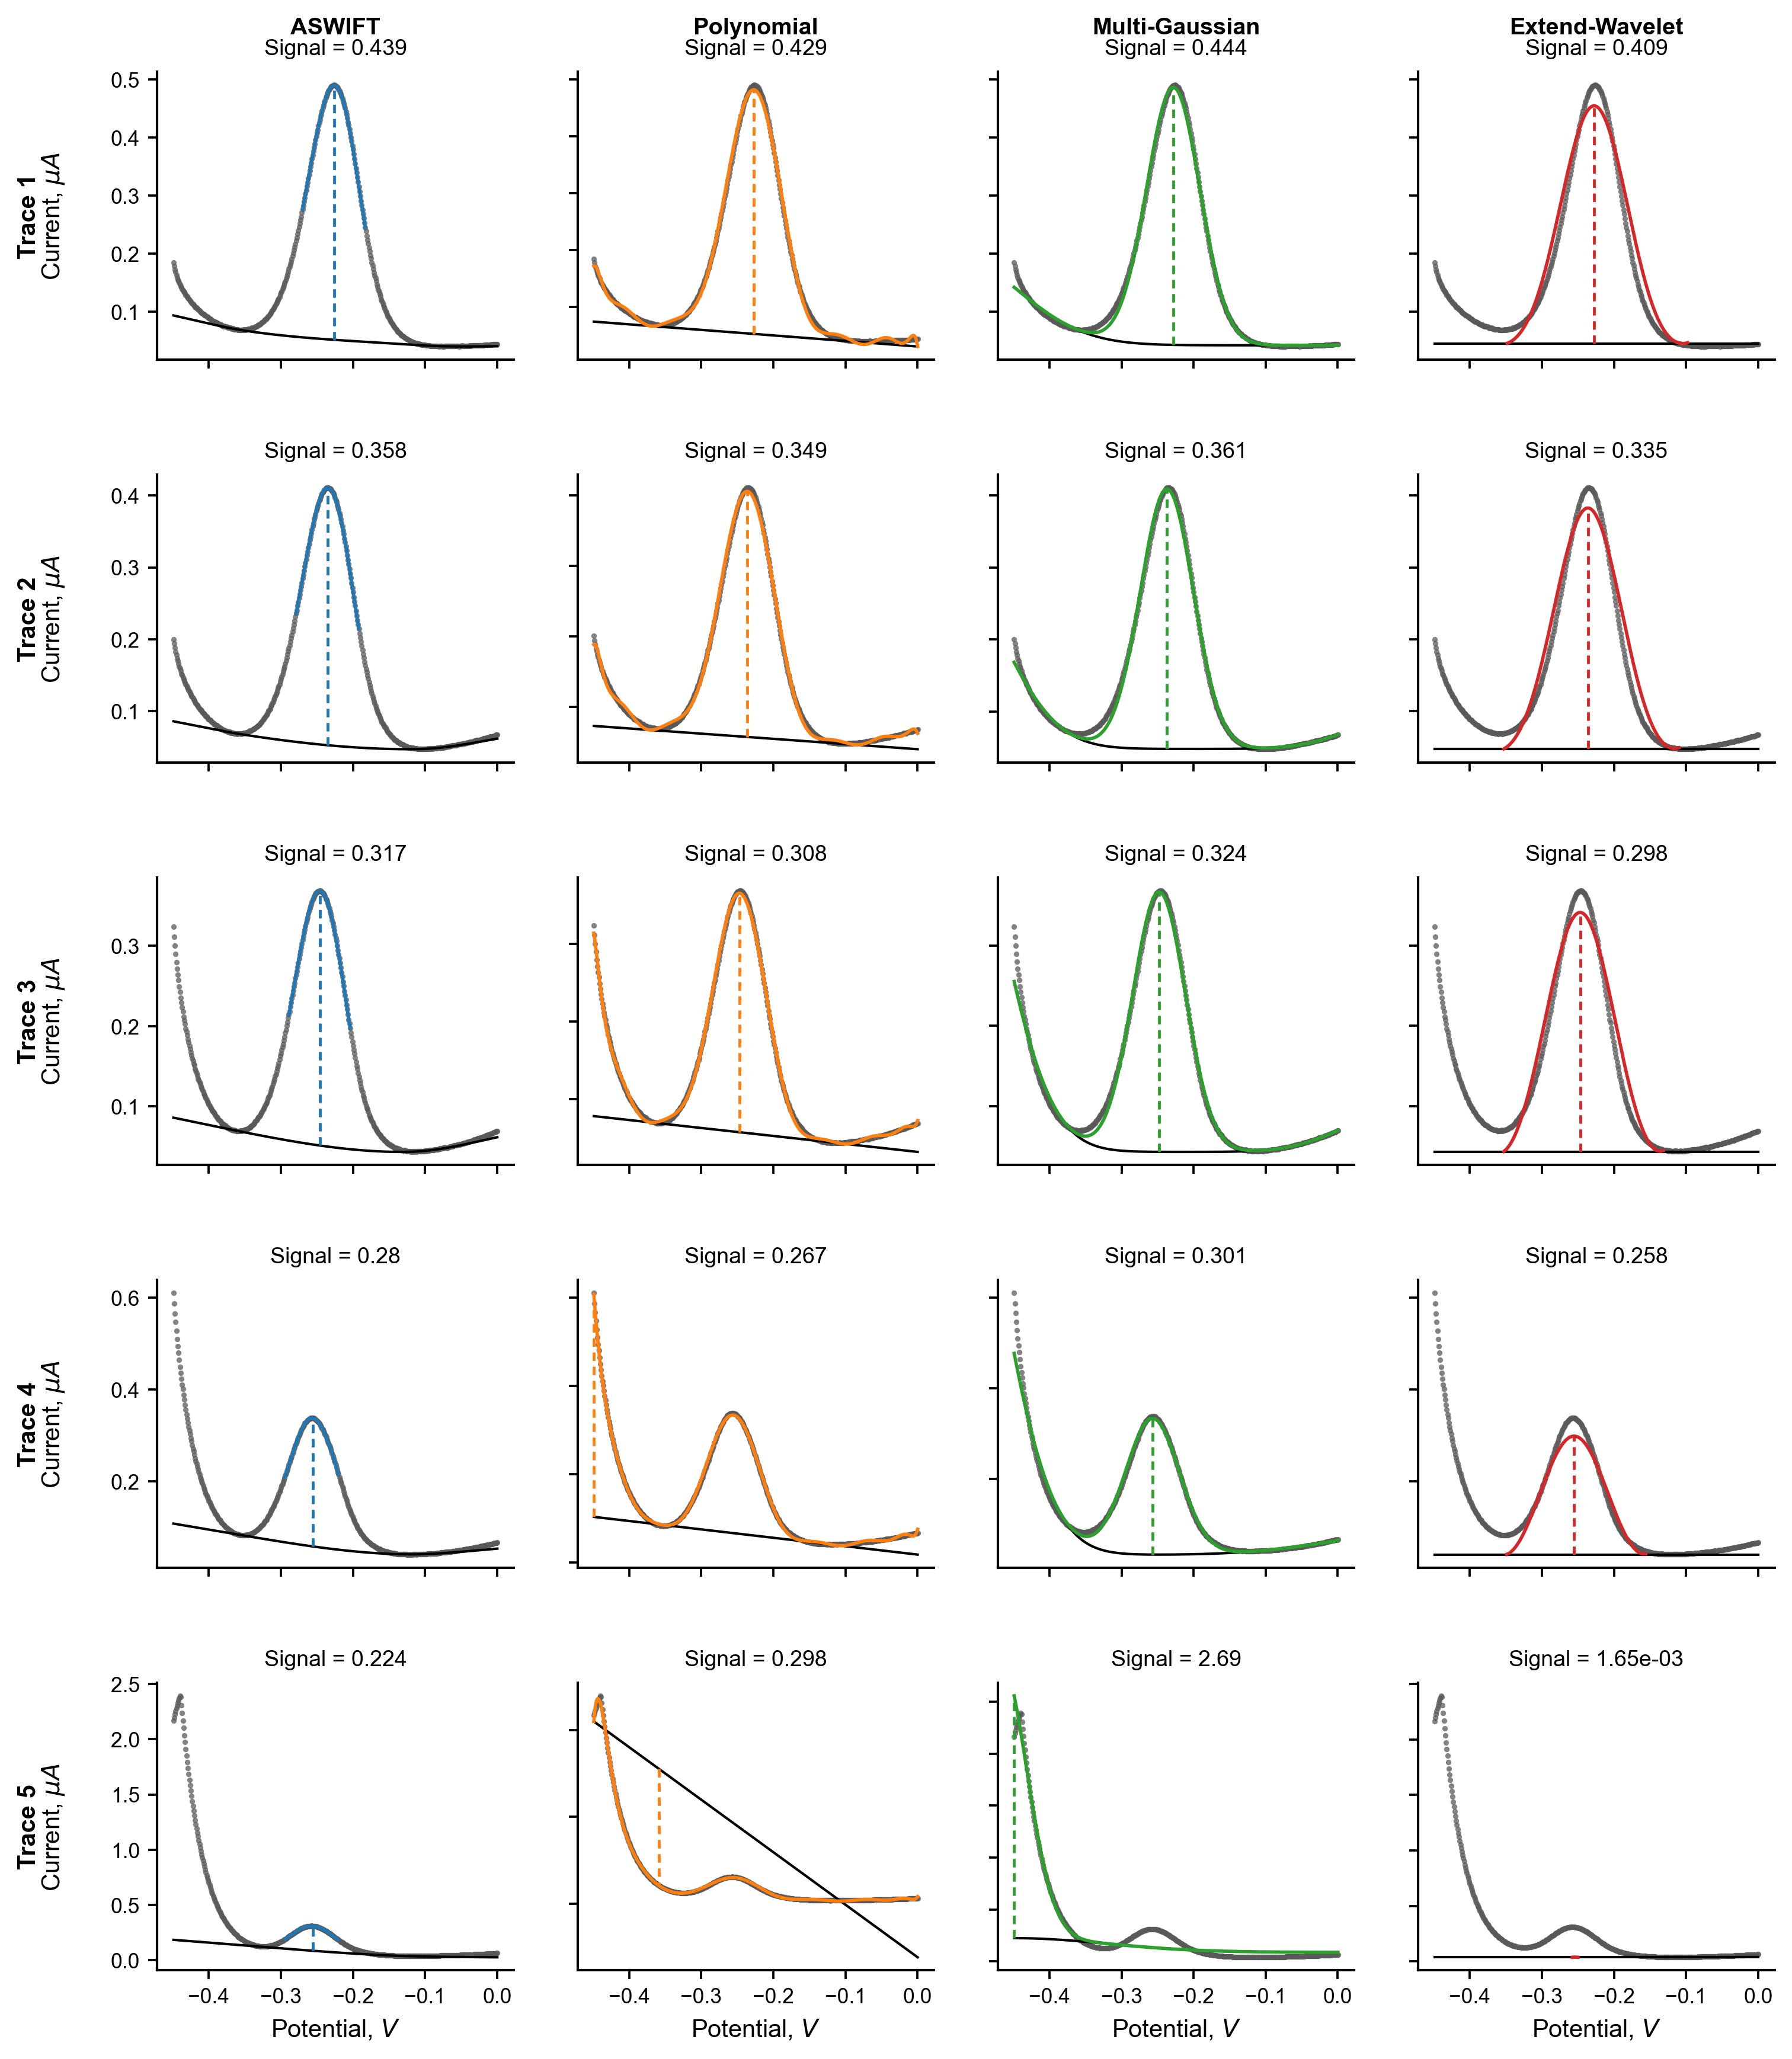

In [6]:
PROJECT_ROOT = None
CONFIG_PATH = Path('../peak_extraction/config/example_config.toml')

voltammogram_csv_paths = [
    Path('/Users/Max_1/Soh Lab/echem/20260213_Dox_BC/CH07/10hz-1.csv'),
    Path('/Users/Max_1/Soh Lab/echem/20260213_Dox_BC/CH07/10hz-10.csv'),
    Path('/Users/Max_1/Soh Lab/echem/20260213_Dox_BC/CH07/10hz-20.csv'),
    Path('/Users/Max_1/Soh Lab/echem/20260213_Dox_BC/CH07/10hz-30.csv'),
    Path('/Users/Max_1/Soh Lab/echem/20260213_Dox_BC/CH07/10hz-45.csv'),
]

row_labels = [
    'Trace 1',
    'Trace 2',
    'Trace 3',
    'Trace 4',
    'Trace 5',
]

# Use {} for the default mask_multichannel_outliers settings.
# Use None to plot every finite raw point.
raw_data_outlier_kwargs = {}

fig, axes = plot_si_fit_grid(
    voltammogram_csv_paths,
    config_path=CONFIG_PATH,
    project_root=PROJECT_ROOT,
    channel=0,
    row_labels=row_labels,
    raw_data_outlier_kwargs=None,
    save_stem='SI_5',
)
plt.show()


/Users/Max_1/PycharmProjects/aswift_figures/peak_extraction/extract_peaks.py:1088: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(volts, cur0, degree)
/Users/Max_1/PycharmProjects/aswift_figures/peak_extraction/extract_peaks.py:1088: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(volts, cur0, degree)
/Users/Max_1/PycharmProjects/aswift_figures/peak_extraction/extract_peaks.py:1088: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(volts, cur0, degree)
/Users/Max_1/PycharmProjects/aswift_figures/peak_extraction/extract_peaks.py:1088: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(volts, cur0, degree)
/Users/Max_1/PycharmProjects/aswift_figures/peak_extraction/extract_peaks.py:1088: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(volts, cur0, degree)
/Users/Max_1/PycharmProjects/aswift_figures/peak_extraction/extract_peaks.py:1088: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(volts, cur0, 

Saved to: /Users/Max_1/PycharmProjects/aswift_figures/figures/figure_exports


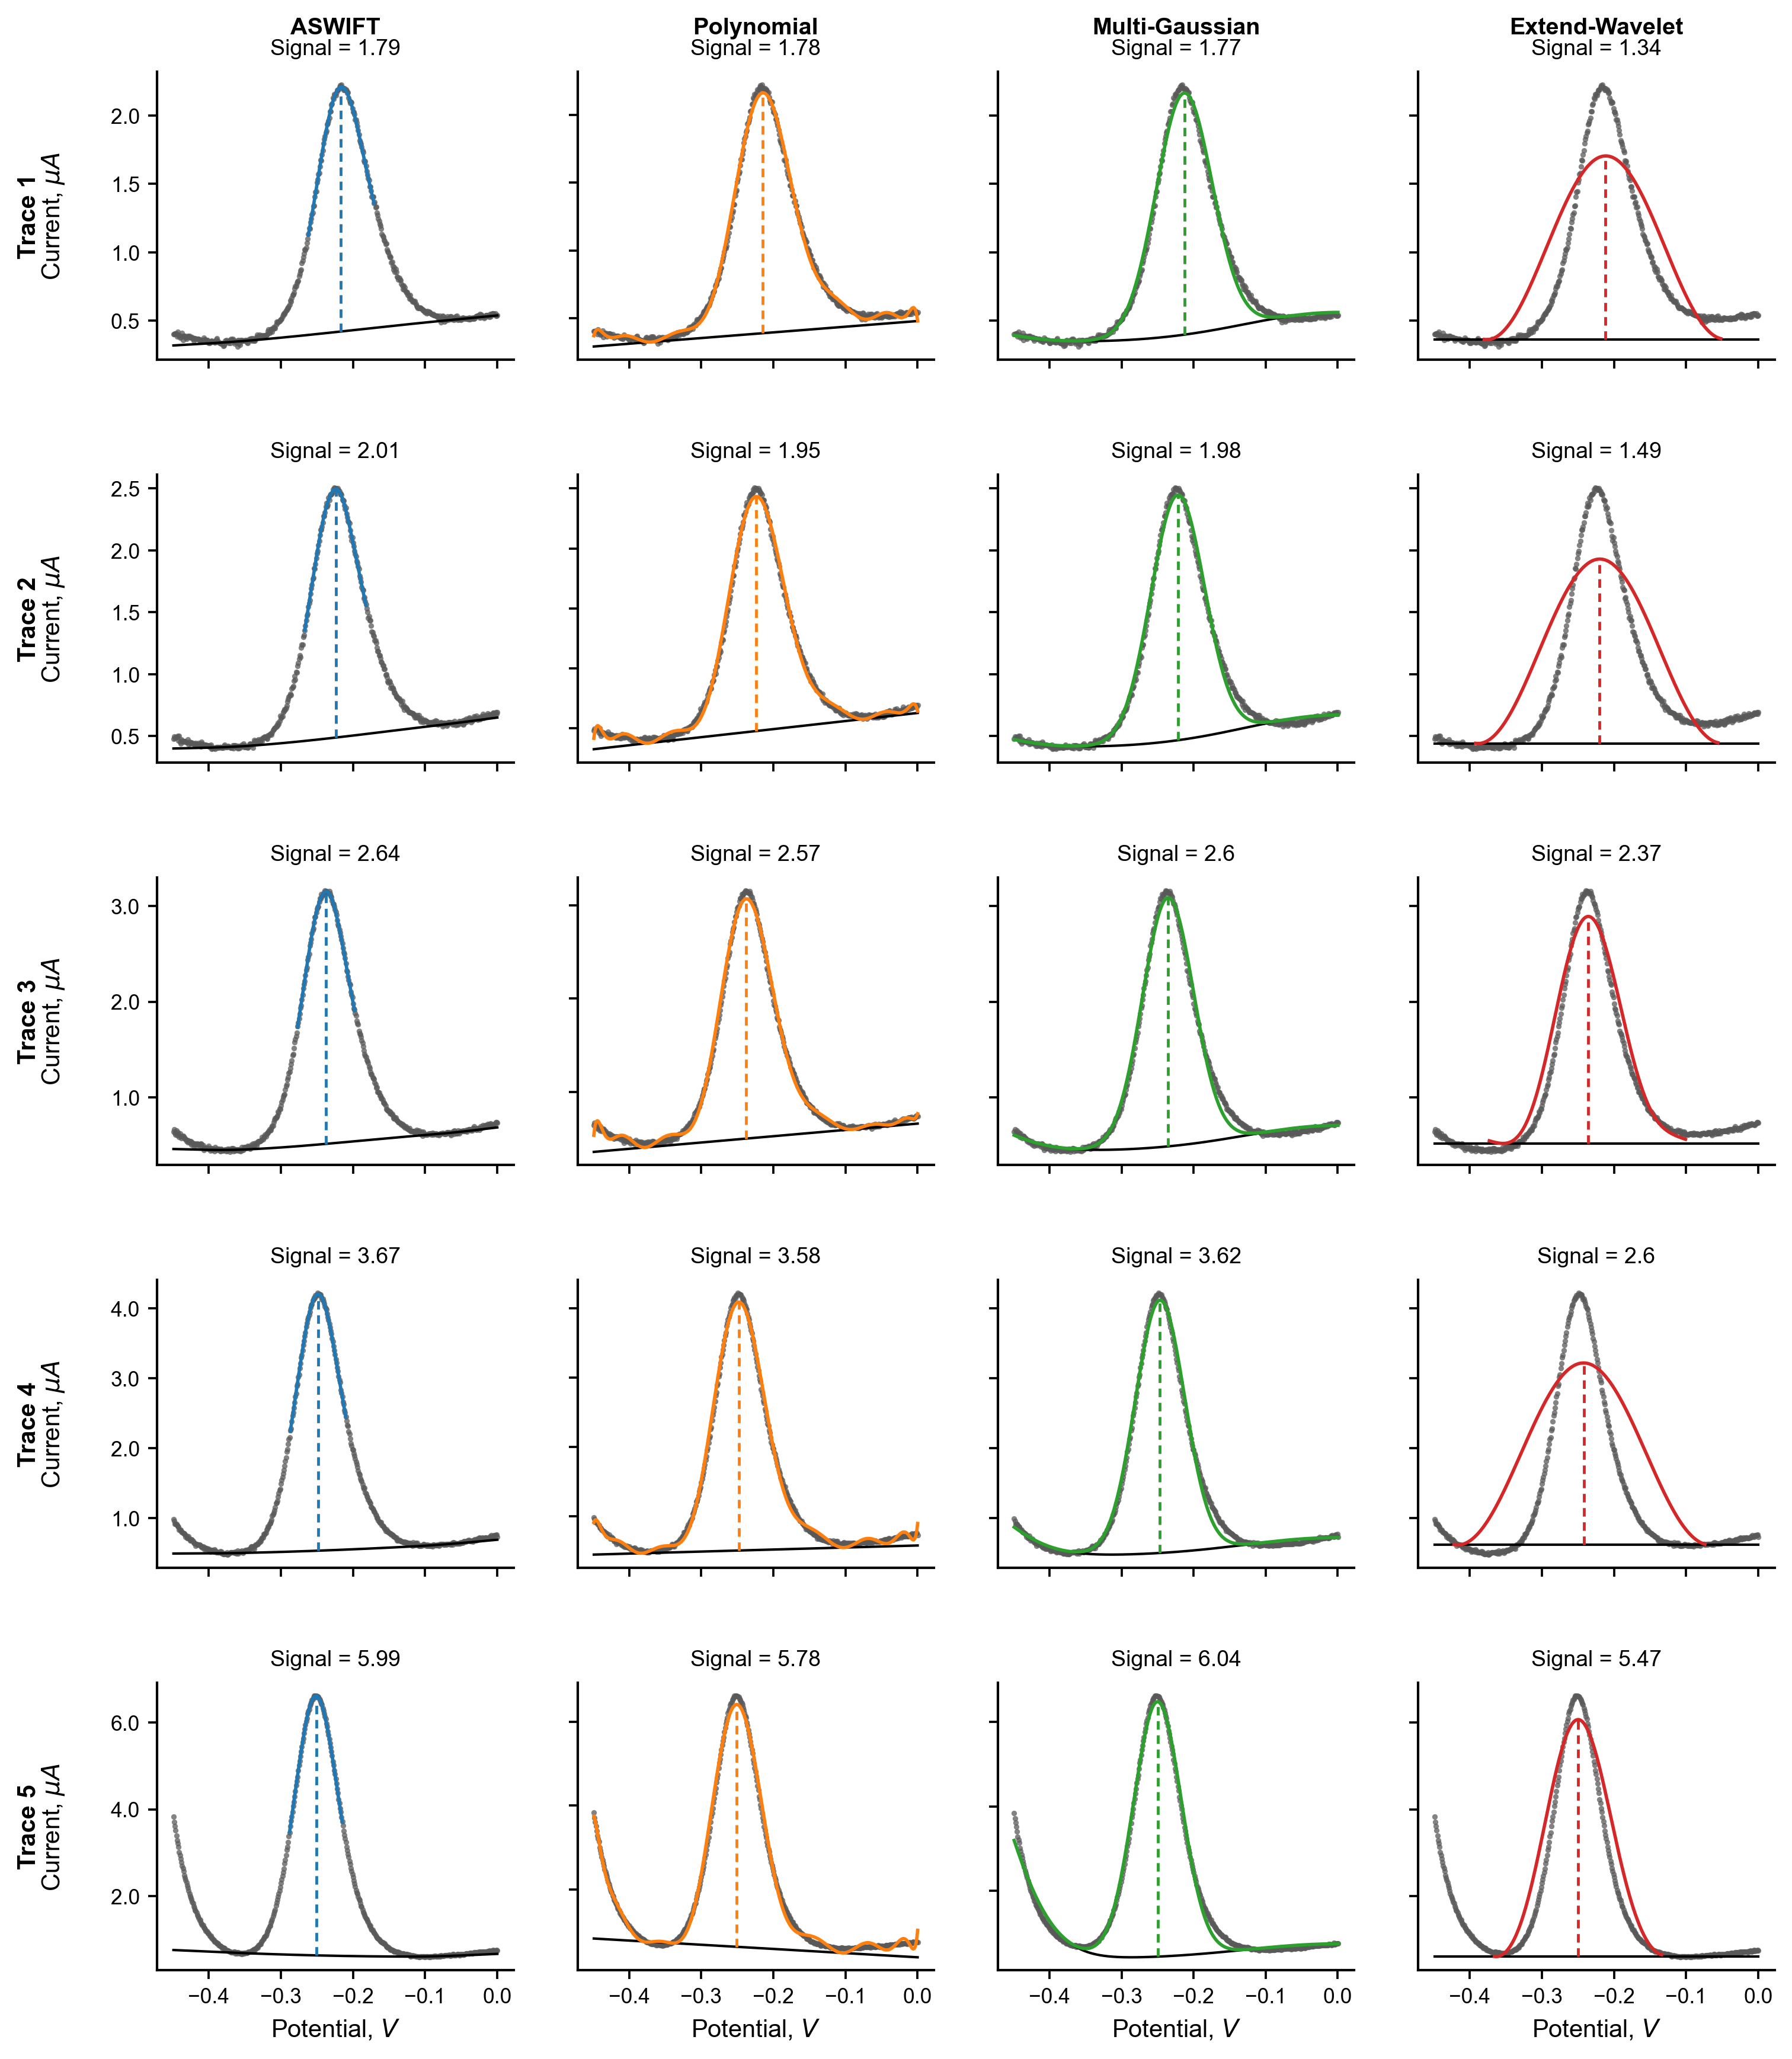

In [7]:
PROJECT_ROOT = None
CONFIG_PATH = Path('../peak_extraction/config/example_config.toml')

voltammogram_csv_paths = [
    Path('/Users/Max_1/Soh Lab/echem/20260213_Dox_BC/CH07/200hz-1.csv'),
    Path('/Users/Max_1/Soh Lab/echem/20260213_Dox_BC/CH07/200hz-10.csv'),
    Path('/Users/Max_1/Soh Lab/echem/20260213_Dox_BC/CH07/200hz-20.csv'),
    Path('/Users/Max_1/Soh Lab/echem/20260213_Dox_BC/CH07/200hz-30.csv'),
    Path('/Users/Max_1/Soh Lab/echem/20260213_Dox_BC/CH07/200hz-45.csv'),
]

row_labels = [
    'Trace 1',
    'Trace 2',
    'Trace 3',
    'Trace 4',
    'Trace 5',
]

# Use {} for the default mask_multichannel_outliers settings.
# Use None to plot every finite raw point.
raw_data_outlier_kwargs = {}

fig, axes = plot_si_fit_grid(
    voltammogram_csv_paths,
    config_path=CONFIG_PATH,
    project_root=PROJECT_ROOT,
    channel=0,
    row_labels=row_labels,
    raw_data_outlier_kwargs=None,
    save_stem='SI_6',
)
plt.show()


Failed fit: 150hz-1.csv, channel 1, reason: No peaks found
Failed fit: 150hz-1.csv, channel 2, reason: No peaks found
Failed fit: 150hz-1.csv, channel 1, reason: No peaks found.
Failed fit: 150hz-1.csv, channel 2, reason: No peaks found.


/Users/Max_1/PycharmProjects/aswift_figures/peak_extraction/extract_peaks.py:1088: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(volts, cur0, degree)
/Users/Max_1/PycharmProjects/aswift_figures/peak_extraction/extract_peaks.py:1088: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(volts, cur0, degree)
/Users/Max_1/PycharmProjects/aswift_figures/peak_extraction/extract_peaks.py:1088: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(volts, cur0, degree)


Failed fit: 150hz-1.csv, channel 1, reason: No peaks found
Failed fit: 150hz-1.csv, channel 2, reason: No peaks found
Failed fit: 150hz-6.csv, channel 1, reason: No peaks found
Failed fit: 150hz-6.csv, channel 2, reason: No peaks found
Failed fit: 150hz-6.csv, channel 1, reason: No peaks found.
Failed fit: 150hz-6.csv, channel 2, reason: No peaks found.


/Users/Max_1/PycharmProjects/aswift_figures/peak_extraction/extract_peaks.py:1088: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(volts, cur0, degree)
/Users/Max_1/PycharmProjects/aswift_figures/peak_extraction/extract_peaks.py:1088: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(volts, cur0, degree)
/Users/Max_1/PycharmProjects/aswift_figures/peak_extraction/extract_peaks.py:1088: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(volts, cur0, degree)


Failed fit: 150hz-6.csv, channel 1, reason: No peaks found
Failed fit: 150hz-6.csv, channel 2, reason: No peaks found
Failed fit: 150hz-9.csv, channel 1, reason: No peaks found
Failed fit: 150hz-9.csv, channel 2, reason: No peaks found
Failed fit: 150hz-9.csv, channel 1, reason: No peaks found.
Failed fit: 150hz-9.csv, channel 2, reason: No peaks found.


...

Failed fit: 150hz-9.csv, channel 1, reason: No peaks found
Failed fit: 150hz-9.csv, channel 2, reason: No peaks found
Failed fit: 150hz-28.csv, channel 1, reason: No peaks found
Failed fit: 150hz-28.csv, channel 2, reason: No peaks found
Failed fit: 150hz-28.csv, channel 1, reason: No peaks found.
Failed fit: 150hz-28.csv, channel 2, reason: No peaks found.


/Users/Max_1/PycharmProjects/aswift_figures/peak_extraction/extract_peaks.py:1088: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(volts, cur0, degree)
/Users/Max_1/PycharmProjects/aswift_figures/peak_extraction/extract_peaks.py:1088: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(volts, cur0, degree)
/Users/Max_1/PycharmProjects/aswift_figures/peak_extraction/extract_peaks.py:1088: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(volts, cur0, degree)


Failed fit: 150hz-28.csv, channel 1, reason: No peaks found
Failed fit: 150hz-28.csv, channel 2, reason: No peaks found
Failed fit: 150hz-40.csv, channel 1, reason: No peaks found
Failed fit: 150hz-40.csv, channel 2, reason: No peaks found
Failed fit: 150hz-40.csv, channel 1, reason: No peaks found.
Failed fit: 150hz-40.csv, channel 2, reason: No peaks found.


/Users/Max_1/PycharmProjects/aswift_figures/peak_extraction/extract_peaks.py:1088: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(volts, cur0, degree)
/Users/Max_1/PycharmProjects/aswift_figures/peak_extraction/extract_peaks.py:1088: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(volts, cur0, degree)
/Users/Max_1/PycharmProjects/aswift_figures/peak_extraction/extract_peaks.py:1088: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(volts, cur0, degree)


Failed fit: 150hz-40.csv, channel 1, reason: No peaks found
Failed fit: 150hz-40.csv, channel 2, reason: No peaks found
Saved to: /Users/Max_1/PycharmProjects/aswift_figures/figures/figure_exports


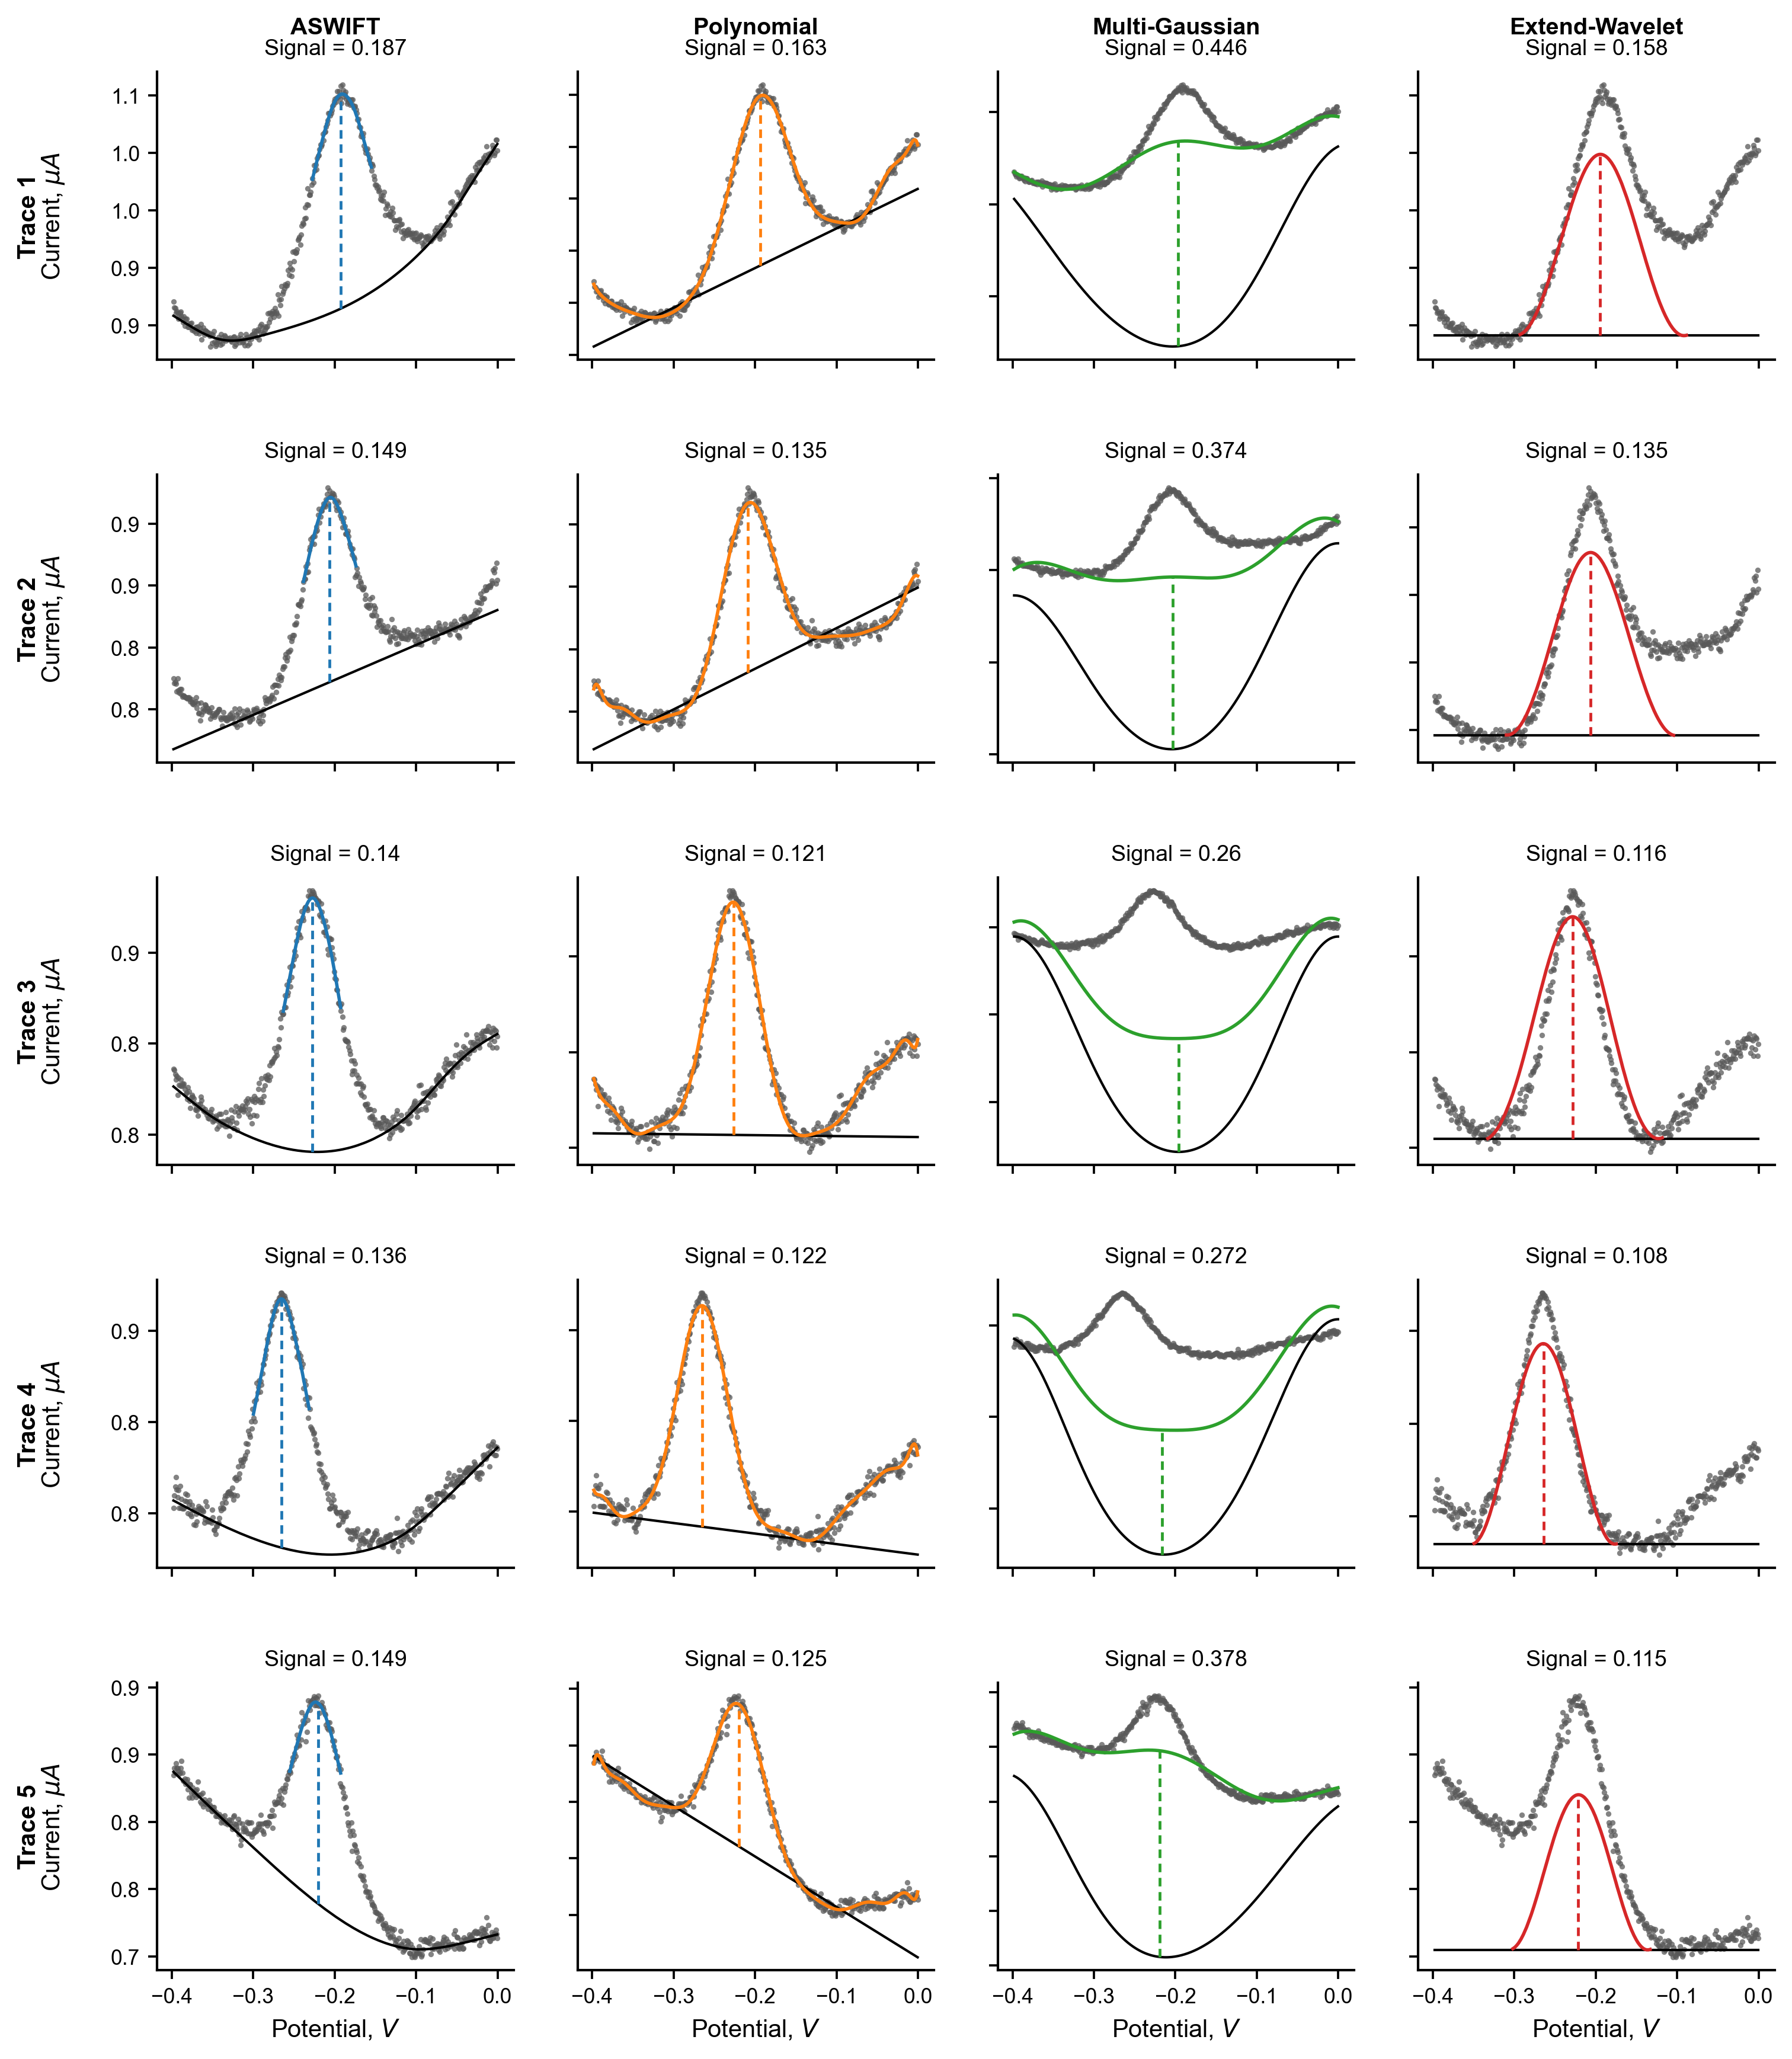

In [8]:
PROJECT_ROOT = None
CONFIG_PATH = Path('../peak_extraction/config/example_config.toml')

voltammogram_csv_paths = [
    Path('/Users/Max_1/Soh Lab/echem/20250813 E1 npAu Probe/01_Binding Curve/150hz-1.csv'),
    Path('/Users/Max_1/Soh Lab/echem/20250813 E1 npAu Probe/01_Binding Curve/150hz-6.csv'),
    Path('/Users/Max_1/Soh Lab/echem/20250813 E1 npAu Probe/01_Binding Curve/150hz-9.csv'),
    Path('/Users/Max_1/Soh Lab/echem/20250813 E1 npAu Probe/01_Binding Curve/150hz-28.csv'),
    Path('/Users/Max_1/Soh Lab/echem/20250813 E1 npAu Probe/01_Binding Curve/150hz-40.csv'),
]

row_labels = [
    'Trace 1',
    'Trace 2',
    'Trace 3',
    'Trace 4',
    'Trace 5',
]

# Use {} for the default mask_multichannel_outliers settings.
# Use None to plot every finite raw point.
raw_data_outlier_kwargs = {}

fig, axes = plot_si_fit_grid(
    voltammogram_csv_paths,
    config_path=CONFIG_PATH,
    project_root=PROJECT_ROOT,
    channel=0,
    row_labels=row_labels,
    raw_data_outlier_kwargs=None,
    save_stem='SI_7',
)
plt.show()
